<div style="text-align: center;">

<h1 style="color:#e06666; font-weight: normal; margin-bottom: 10px;">
EN3160 Assignment 01
</h1>

<h2 style="color:#e06666; font-weight: normal; line-height: 1.5; margin-top: 0;">
Intensity Transformations and Neighborhood<br>
Filtering
</h2>

<!-- <br><br> -->

<h3 style="font-family: 'Times New Roman', serif; font-weight: normal; margin-top: 0; line-height: 1.4;">
Dhananjaya K.T.G.T.N.<br>
230138K
</h3>

<br>
<!-- <h4 style="font-family: 'Times New Roman', serif; font-weight: normal;">
September 4, 2026
</h4> -->

</div>

### 1. Intensity Transformation

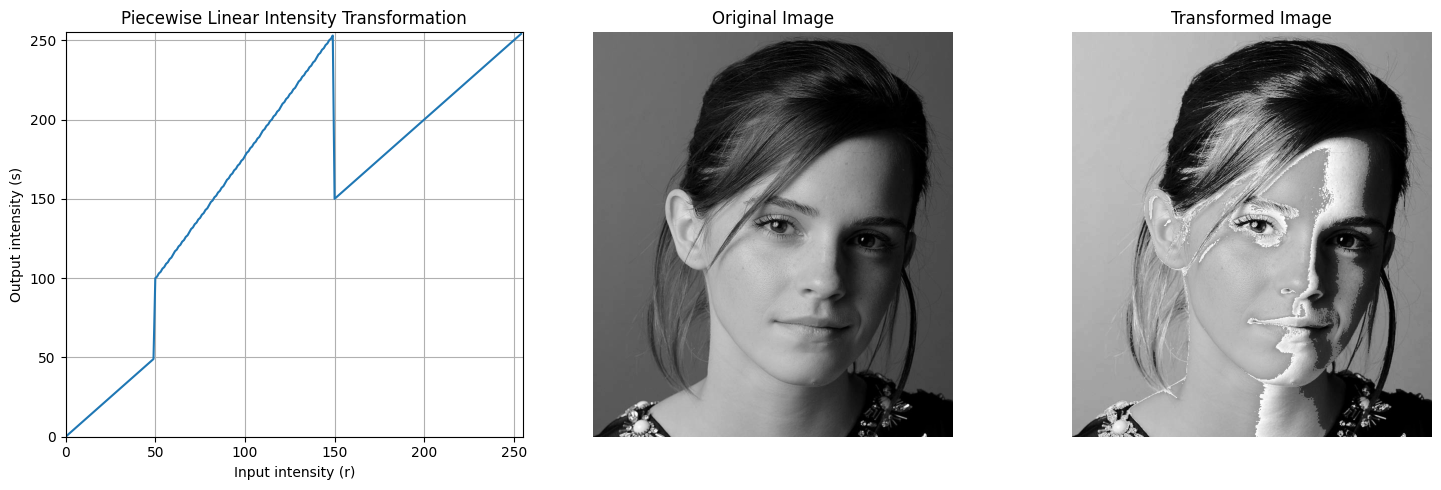

In [43]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
    transformed = np.zeros_like(im, dtype=np.uint8)

    for i in range(len(breakpoints) - 1):
        x0, y0 = breakpoints[i]
        x1, y1 = breakpoints[i + 1]

        # Calculate the slope (m) and intercept (b) of the line segment
        if x1 - x0 != 0:
            m = (y1 - y0) / (x1 - x0)
            b = y0 - m * x0
        else:
            m = 0
            b = y0

        # Apply the linear transformation for the current segment
        mask = (im >= x0) & (im < x1)
        transformed[mask] = np.clip(m * im[mask] + b, 0, 255)
    return transformed.astype(np.uint8)


# Read image using OpenCV
im = cv.imread("images/emma.jpeg", cv.IMREAD_GRAYSCALE)

# Define breakpoints
breakpoints = np.array([[0, 0], [50, 50],[50, 100], [150, 255],[150, 150], 
                        [255, 255],])
transformed = intensity_transform(im, breakpoints)

# Plot the transformation function
r = np.arange(255)
s = intensity_transform(r, breakpoints)

plt.figure(figsize=(15, 5))
# Plot 1: Transformation function
plt.subplot(1, 3, 1)
plt.plot(r, s)
plt.xlabel("Input intensity (r)")
plt.ylabel("Output intensity (s)")
plt.title("Piecewise Linear Intensity Transformation")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid()
# Plot 2: Original image
plt.subplot(1, 3, 2)
plt.imshow(im, cmap="gray")
plt.title("Original Image")
plt.axis("off")
# Plot 3: Transformed image
plt.subplot(1, 3, 3)
plt.imshow(transformed, cmap="gray")
plt.title("Transformed Image")
plt.axis("off")
plt.tight_layout()
plt.show()